# CALIPR tuning on the synthetic phantom — V1

Tuning of the CALIPR-style subspace reconstruction (`Recon_CALIPR_V1.ipynb`, code in
`synth/calipr.py`) on the **synthetic phantom v2** (`synth/phantom.py`; WM 250–300 ms,
GM 310–370 ms, lesions 357.5 / 192.5 ms, centred partial-volume truth). No real subject data.

**Fixed for all stages (researcher's decision, 2026-10-01).** The phantom's **true coil maps**
(`truth_COR.npz['sens']`, one map set, unit RSS like ENLIVE): coil-map calibration is specific
to the scanner's coils and is tuned on real data. Task 1 (`CALIPR_LesionBias_V1.ipynb`) showed
that with self-calibrated maps the map error dominates the lesion bias, so fixing the maps lets
each stage show the reconstruction's own trade-offs. Noisy phantom (noise 0.18 × TI800 k-space
RMS, as measured on the real data), coronal plane, both echo groups, shared combination and fit
(`pipeline_utils`), exactly as the final pipeline.

**Stages** (each run only after approval): 1 λ × iterations · 2 subspace size K · 3 regulariser
form · 4 phase handling · 5 dictionary range/scaling · 6 confirmation on all planes and with
ENLIVE maps.

**Metrics.**
* *Noise / local error*: RMSE of T1 − `ideal` over eroded WM and over eroded GM (voxelwise).
  WM and GM T1 vary smoothly by design (bell-shaped within each tissue), so the SD of T1 within a
  tissue is no longer a noise measure; the error against the voxelwise ideal is.
* *Bias*: mean T1 vs `ideal` per tissue and per lesion (`pu.evaluate_t1`; lesion masks = voxels
  holding ≥ half the lesion's peak partial-volume fraction). The 2 mm lesions are 2 voxels with
  peak PV 0.25 and are reported but not used for decisions.
* *Lesion contrast*: mean |bias vs ideal| over the 4–10 mm lesions (L1–3, L5–7).
* Images are judged by eye: the grids below follow `T1map_3plane_SR_V1.ipynb` section 13.

## 1. Environment and configuration

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion

BART_PATH = os.environ.get('BART_TOOLBOX_PATH', '/Users/jackewins/bart/')
os.environ['BART_TOOLBOX_PATH'] = BART_PATH
sys.path.append(os.path.join(BART_PATH, 'python'))
REPO_DIR = Path(os.environ.get('QT1_REPO_DIR', Path.cwd()))
sys.path.insert(0, str(REPO_DIR / 'synth'))
import pipeline_utils as pu
import run_bias_experiments as rbe
import phantom as ph

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 72

PHANTOM_DIR = Path(os.environ.get('QT1_PHANTOM_DIR', Path.home() / 'work' / 'phantom'))   # phantom v2
CACHE       = Path(os.environ.get('QT1_TUNE_CACHE', Path.home() / 'work' / 'tune'))
os.environ['QT1_PHANTOM_DIR'] = str(PHANTOM_DIR)
PLANE = 'COR'
truth = dict(np.load(PHANTOM_DIR / f'truth_{PLANE}.npz'))
scans = ph.load_scans(PHANTOM_DIR)[PLANE]
TI = np.array([s['info']['TI_s'] for s in scans]); TR = np.array([s['info']['TR_s'] for s in scans])
sp = pu.spacing_of(scans[-1]['info']); ASP = sp[0] / sp[1]
WM_E = binary_erosion(truth['label'] == 5); GM_E = binary_erosion(truth['label'] == 4)
LES = [3, 4, 5, 7, 8, 9]                      # evaluate_t1 rows of L1-3 (long T1) and L5-7 (short T1)
ZL = int(np.argmax(truth['lesion_frac_by_id'][0].sum(axis=(0, 1))))   # slice through the 10 mm lesions
RSS = np.sqrt(np.sum(np.abs(truth['sens']) ** 2, -1))                  # image weighting of unit-RSS maps
print('phantom', PHANTOM_DIR, '| cache', CACHE, '| lesion slice', ZL)

def cond(lam, it, data='noisy', maps='true'):
    return f'{data}:{maps}:CAL:lam{lam}i{it}'

def load(c):
    f = CACHE / f"{PLANE}_{c.replace(':', '_')}.npz"
    if not f.exists():
        rbe.run(CACHE, c)
    z = dict(np.load(f))
    t1 = 1000 * z['T1_s']
    z['rows'] = pu.evaluate_t1(z['T1_s'], truth)
    z['rmse_wm'] = float(np.sqrt(np.nanmean((t1 - truth['T1_ideal_ms'])[WM_E] ** 2)))
    z['rmse_gm'] = float(np.sqrt(np.nanmean((t1 - truth['T1_ideal_ms'])[GM_E] ** 2)))
    z['les_abs'] = float(np.mean([abs(z['rows'][i]['bias_vs_ideal_pct']) for i in LES]))
    return z

def metrics_table(keys, R, label):
    names = [R[keys[0]]['rows'][i]['region'].replace('lesion ', 'L').replace(' mm)', ')') for i in LES]
    print(f"{label:16s} {'WM RMSE':>8s} {'GM RMSE':>8s} {'WM bias':>8s} {'GM bias':>8s} " + ' '.join(f'{n:>8s}' for n in names)
          + f" {'mean|L|':>8s} {'min':>5s}")
    for k in keys:
        z = R[k]; r = z['rows']
        print(f"{str(k):16s} {z['rmse_wm']:7.1f}  {z['rmse_gm']:7.1f}  {r[0]['bias_vs_ideal_pct']:+7.1f}% {r[1]['bias_vs_ideal_pct']:+7.1f}% "
              + ' '.join(f"{r[i]['bias_vs_ideal_pct']:+7.1f}%" for i in LES) + f" {z['les_abs']:7.1f}% {float(z['seconds']) / 60:5.1f}")

phantom /root/work/phantom | cache /root/work/tune | lesion slice 26


## 2. Stage 1 — regularisation weight λ × iterations

`pics -e -S -R W:7:0:<λ> -i <iter> -U` with everything else as V1 (K = 3 dictionary basis,
per-TI global phase demodulation). λ ∈ {0.0005, 0.001, 0.002, 0.005, 0.01, 0.02} × iterations
∈ {40, 80, 150}; each pair is an independent run from zero (FISTA), so each image is exactly
what that setting produces. λ and iterations interact: FISTA starts from zero, so an
early-stopped reconstruction is smoother than the converged one at the same λ.

Figures, as in the LLR sweep:
1. **Signed (PSIR) signal at TI800**, slice through the 10 mm lesions: rows λ, columns
   iterations; last column the resolution-limited ideal (weighted by the coil RSS like the
   reconstruction). Shared window.
2. **TI150** (near the WM null): where noise and the regulariser show first, and where the
   lesion contrast lives (short-T1 lesions are positive, WM negative, long-T1 lesions more
   negative).
3. **Zoom** on the lesions at TI150.
4. **T1 maps** (same layout) and **T1 − ideal**.
5. **Per-lesion T1 zooms** at each λ (80 iterations).
6. **Convergence**: relative change of the TI images vs 150 iterations.
7. **Line profiles** through the 10 mm short-T1 lesion (T1 and TI150/TI800), one line per λ.
8. **Trade-off**: WM/GM error (noise) vs lesion bias, one curve per iteration count.

In [2]:
S1_LAMBDAS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
S1_ITERS = [40, 80, 150]
R1 = {(l, i): load(cond(l, i)) for l in S1_LAMBDAS for i in S1_ITERS}
metrics_table(list(R1), R1, '(λ, iterations)')

(λ, iterations)   WM RMSE  GM RMSE  WM bias  GM bias  L1 (10)   L2 (6)   L3 (4)  L5 (10)   L6 (6)   L7 (4)  mean|L|   min
(0.0005, 40)        39.7     40.5     +0.4%    -0.5%    -6.1%    -2.0%    -8.7%    +2.2%    +8.9%    +8.4%     6.1%   3.7
(0.0005, 80)        81.4     68.5     +0.9%    -0.8%    -4.5%    +5.8%    -2.3%    +1.7%    +7.2%    +9.4%     5.2%   4.8
(0.0005, 150)      174.5    163.0     +2.3%    -0.8%    -2.9%    +8.2%    +0.7%    +3.9%    +6.3%   +12.6%     5.8%   6.8
(0.001, 40)         38.1     39.1     +0.4%    -0.5%    -6.3%    -2.2%    -8.8%    +2.4%    +9.0%    +8.4%     6.2%   3.2
(0.001, 80)         72.7     63.0     +0.9%    -0.6%    -4.7%    +4.7%    -3.1%    +1.7%    +7.7%    +9.7%     5.3%   4.3
(0.001, 150)       124.7    138.1     +1.4%    -0.5%    -3.6%    +6.3%    -1.5%    +2.7%    +7.3%   +11.9%     5.5%   7.9
(0.002, 40)         35.2     36.5     +0.4%    -0.4%    -6.5%    -2.7%    -9.2%    +2.7%    +9.2%    +8.7%     6.5%   3.5
(0.002, 80)         53.7

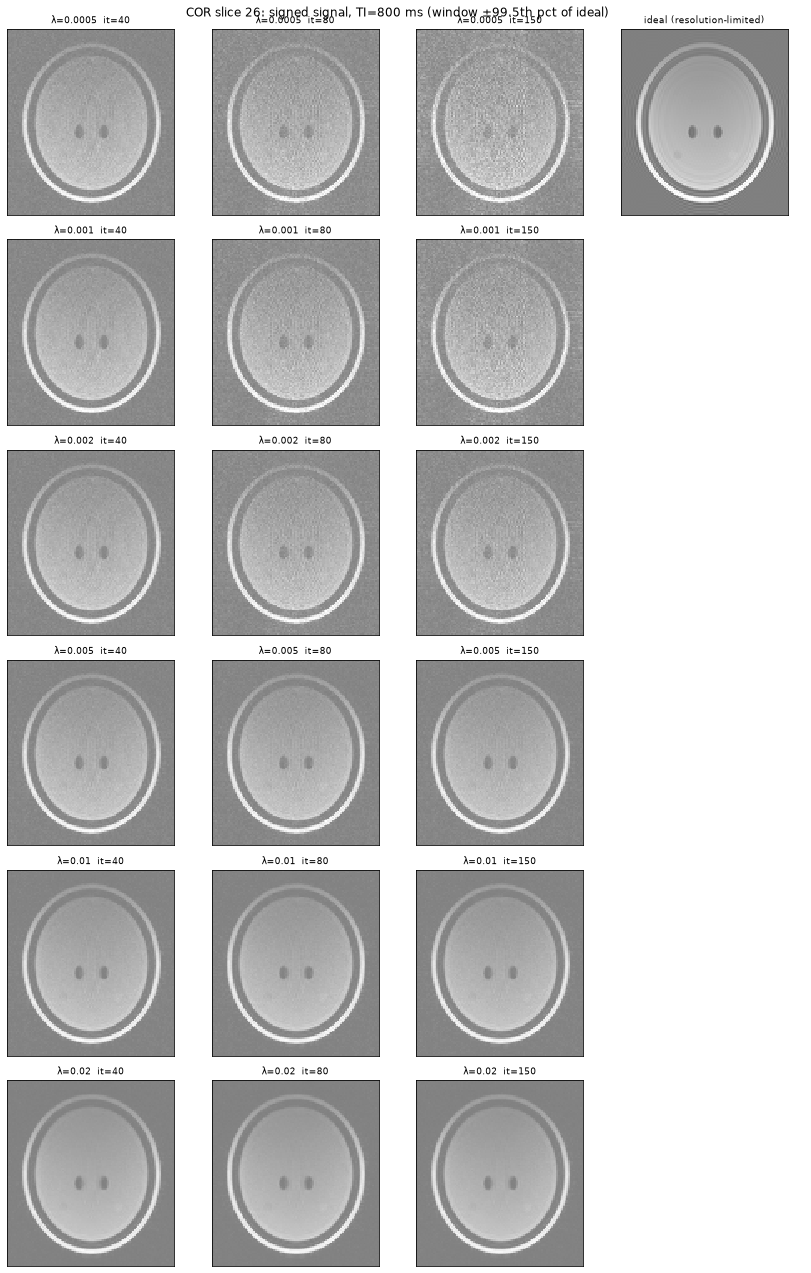

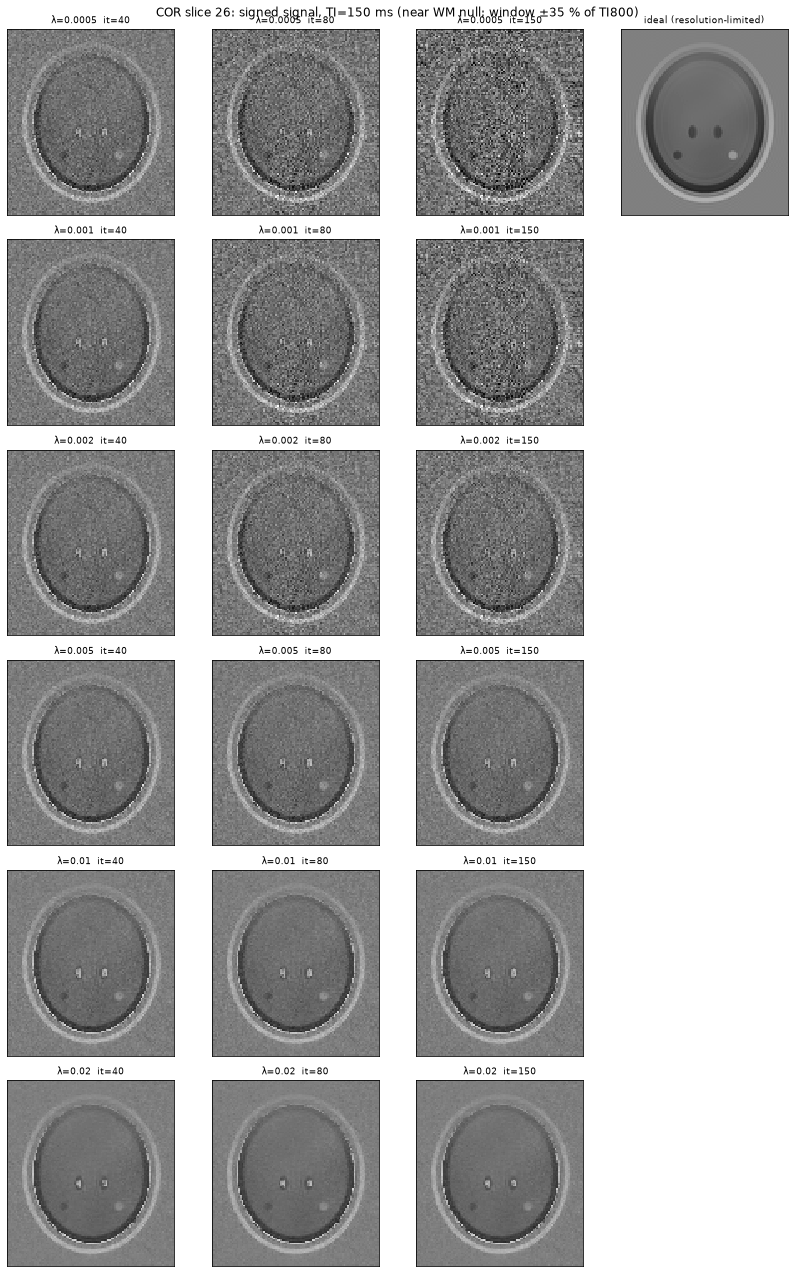

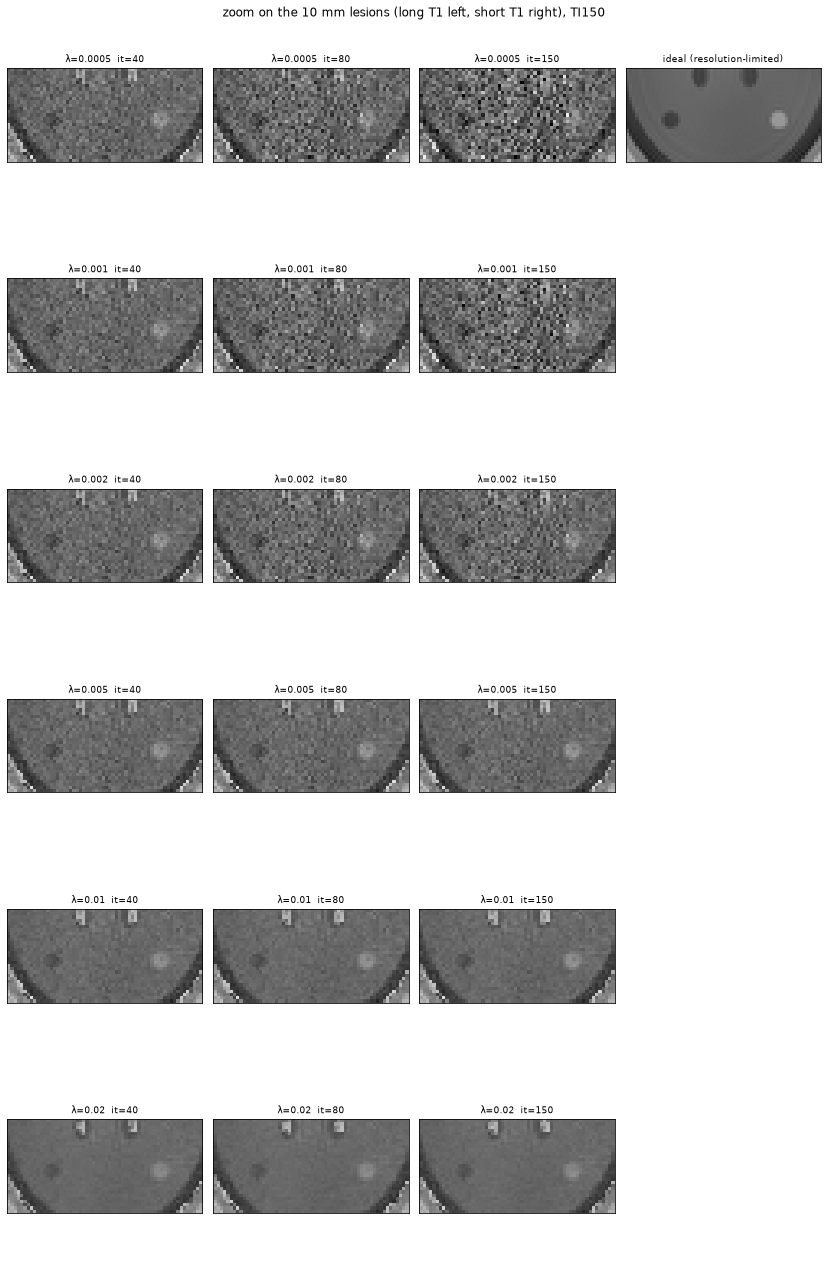

In [3]:
def grid(ti, crop=None, title='', key='signed'):
    ref = R1[S1_LAMBDAS[0], S1_ITERS[-1]][key][:, :, ZL, -1]
    ideal = truth['S_ideal'][:, :, ZL, :] * RSS[:, :, ZL, None]
    a = np.sum(ref[truth['label'][:, :, ZL] == 5]) / np.sum(ideal[..., -1][truth['label'][:, :, ZL] == 5])
    ideal = a * ideal
    vmax = np.percentile(np.abs(ideal[..., -1]), 99.5) * (1.0 if ti == len(TI) - 1 else 0.35)
    nL, nI = len(S1_LAMBDAS), len(S1_ITERS)
    fig, axes = plt.subplots(nL, nI + 1, figsize=(2.9 * (nI + 1), 2.9 * nL + 0.6))
    for r, lam in enumerate(S1_LAMBDAS):
        for c, it in enumerate(S1_ITERS + ['ideal']):
            ax = axes[r, c]
            if it == 'ideal' and r > 0:
                ax.axis('off'); continue
            v = ideal[..., ti] if it == 'ideal' else R1[lam, it][key][:, :, ZL, ti]
            v = v if crop is None else v[crop]
            ax.imshow(v, cmap='gray', vmin=-vmax, vmax=vmax, aspect=ASP, interpolation='nearest')
            ax.set_title('ideal (resolution-limited)' if it == 'ideal' else f'λ={lam}  it={it}', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(title); plt.tight_layout(); plt.show()

grid(len(TI) - 1, None, f'{PLANE} slice {ZL}: signed signal, TI={1000 * TI[-1]:.0f} ms (window ±99.5th pct of ideal)')
grid(1, None, f'{PLANE} slice {ZL}: signed signal, TI={1000 * TI[1]:.0f} ms (near WM null; window ±35 % of TI800)')
fr = truth['lesion_frac_by_id']
x0 = int(np.argmax(fr[0][:, :, ZL].max(1)))
CROP = (slice(x0 - 14, x0 + 15), slice(20, 80))
grid(1, CROP, f'zoom on the 10 mm lesions (long T1 left, short T1 right), TI150')

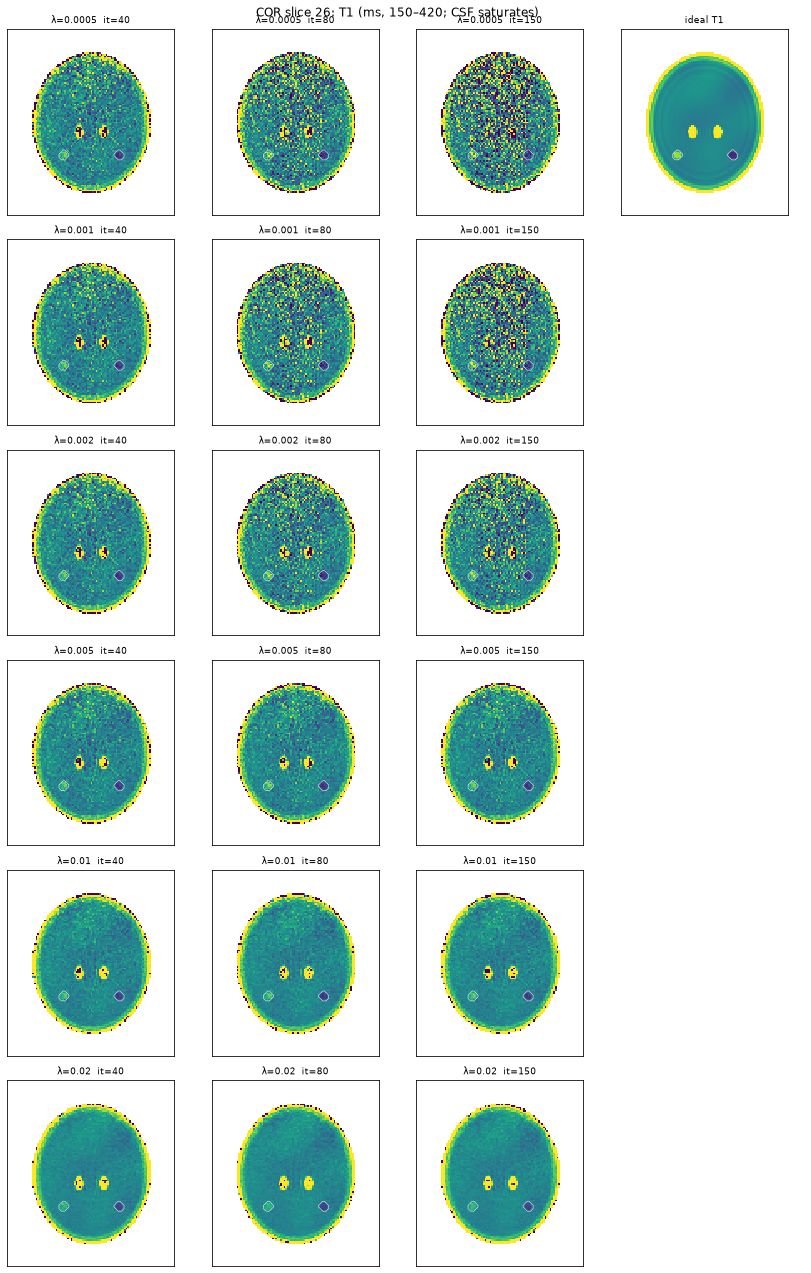

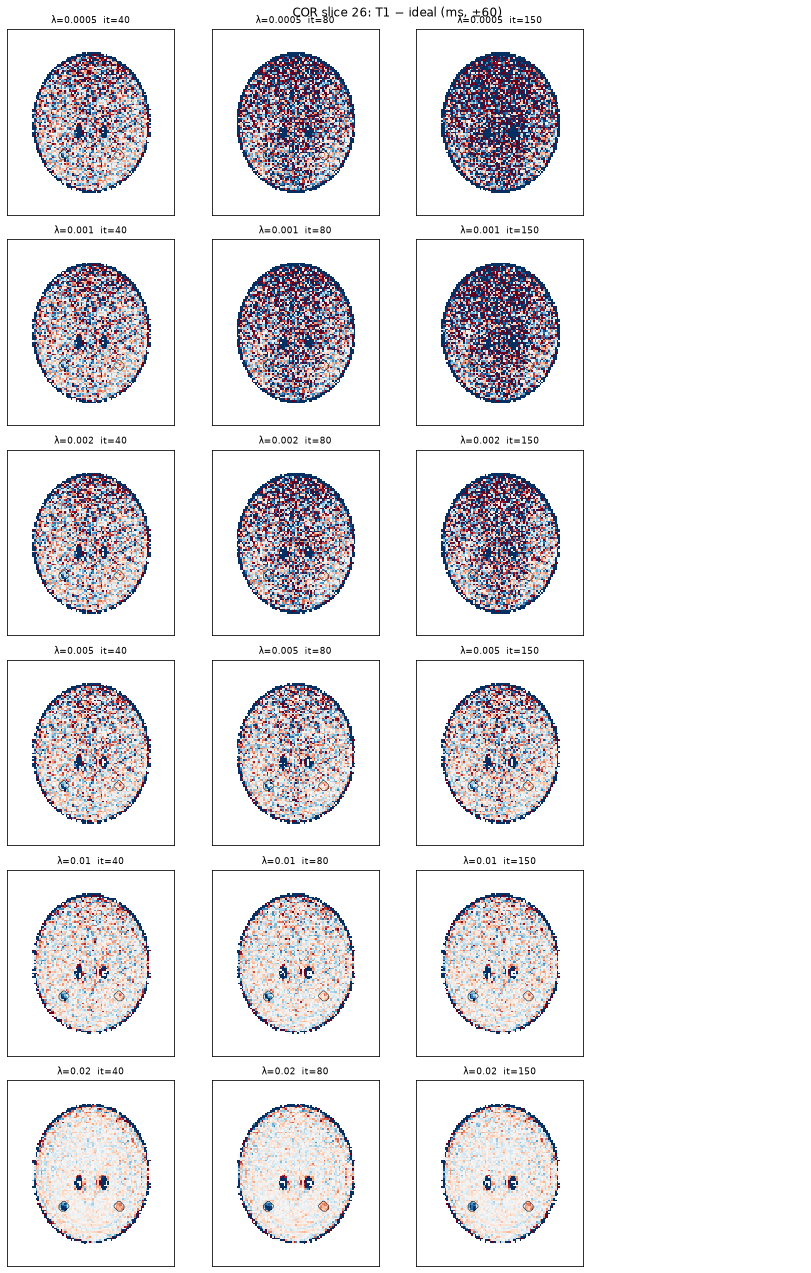

In [4]:
def t1_grid(err=False, crop=None):
    nL, nI = len(S1_LAMBDAS), len(S1_ITERS)
    fig, axes = plt.subplots(nL, nI + 1, figsize=(2.9 * (nI + 1), 2.9 * nL + 0.6))
    for r, lam in enumerate(S1_LAMBDAS):
        for c, it in enumerate(S1_ITERS + ['ideal']):
            ax = axes[r, c]
            if it == 'ideal' and (r > 0 or err):
                ax.axis('off'); continue
            v = truth['T1_ideal_ms'][:, :, ZL] if it == 'ideal' else 1000 * R1[lam, it]['T1_s'][:, :, ZL]
            if err and it != 'ideal':
                v = v - truth['T1_ideal_ms'][:, :, ZL]
            v = v if crop is None else v[crop]
            ax.imshow(v, cmap='RdBu_r' if err else 'viridis', vmin=-60 if err else 150, vmax=60 if err else 420,
                      aspect=ASP, interpolation='nearest')
            ax.contour((truth['lesion_id'][:, :, ZL] > 0) if crop is None else (truth['lesion_id'][:, :, ZL] > 0)[crop],
                       [0.5], colors='k' if err else 'w', linewidths=0.5)
            ax.set_title('ideal T1' if it == 'ideal' else f'λ={lam}  it={it}', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f'{PLANE} slice {ZL}: ' + ('T1 − ideal (ms, ±60)' if err else 'T1 (ms, 150–420; CSF saturates)'))
    plt.tight_layout(); plt.show()

t1_grid()
t1_grid(err=True)

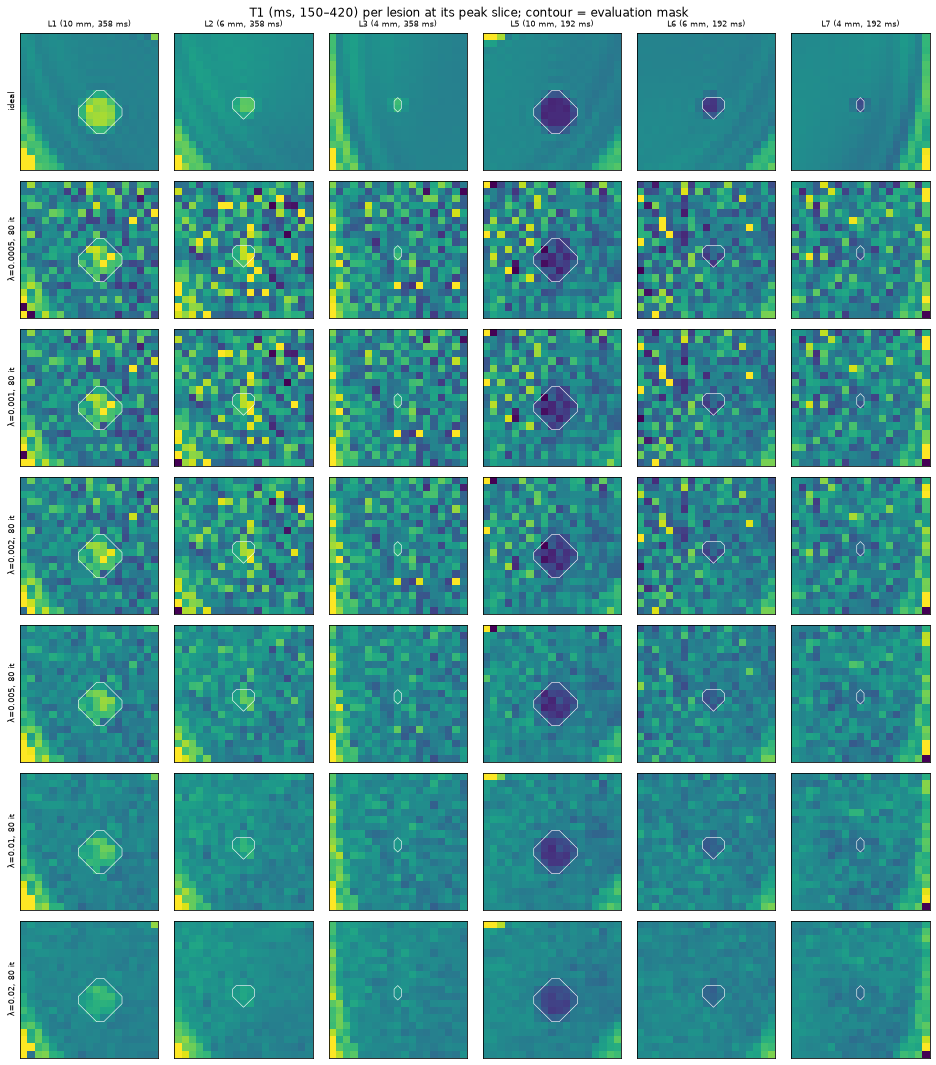

In [5]:
def lesion_zooms(R, keys, labels, h=9):
    frc = truth['lesion_frac_by_id']; order = [0, 1, 2, 4, 5, 6]
    rows_ = [('ideal', truth['T1_ideal_ms'])] + [(lab, 1000 * R[k]['T1_s']) for k, lab in zip(keys, labels)]
    fig, axes = plt.subplots(len(rows_), len(order), figsize=(2.2 * len(order), 2.15 * len(rows_)), squeeze=False)
    for j, i in enumerate(order):
        a0, b0, c0 = np.unravel_index(np.argmax(frc[i]), frc[i].shape)
        sl = (slice(a0 - h, a0 + h + 1), slice(b0 - h, b0 + h + 1), c0)
        for r, (name, vol) in enumerate(rows_):
            a = axes[r, j]
            a.imshow(vol[sl], cmap='viridis', vmin=150, vmax=420, aspect=ASP)
            a.contour(frc[i][sl] >= 0.5 * frc[i].max(), [0.5], colors='w', linewidths=0.6)
            a.set_xticks([]); a.set_yticks([])
            if j == 0: a.set_ylabel(name, fontsize=8)
            if r == 0: a.set_title(f'L{i+1} ({ph.LESIONS[i][2]} mm, {ph.TISSUE[ph.LESIONS[i][0]][1][0]:.0f} ms)', fontsize=8)
    plt.suptitle('T1 (ms, 150–420) per lesion at its peak slice; contour = evaluation mask'); plt.tight_layout(); plt.show()

lesion_zooms(R1, [(l, 80) for l in S1_LAMBDAS], [f'λ={l}, 80 it' for l in S1_LAMBDAS])

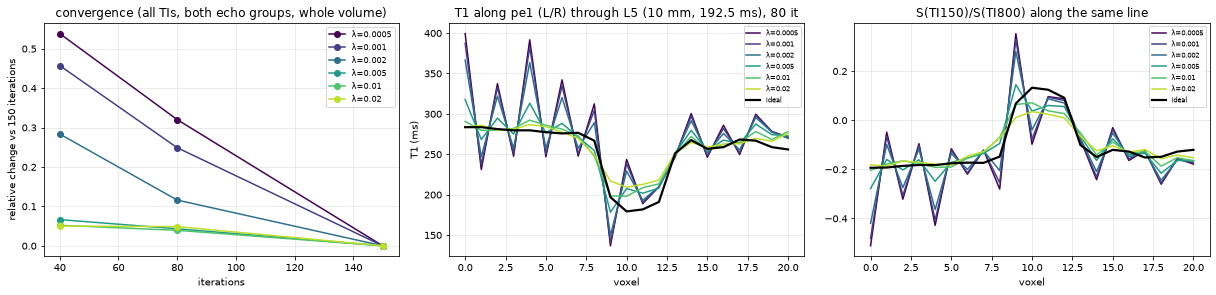

In [6]:
COL = plt.cm.viridis(np.linspace(0, 0.9, len(S1_LAMBDAS)))      # ordered λ: sequential colours
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
for c, lam in zip(COL, S1_LAMBDAS):
    last = np.concatenate([R1[lam, S1_ITERS[-1]][k].ravel() for k in ('img0', 'img1')])
    ch = [np.linalg.norm(np.concatenate([R1[lam, it][k].ravel() for k in ('img0', 'img1')]) - last) / np.linalg.norm(last) for it in S1_ITERS]
    ax[0].plot(S1_ITERS, ch, 'o-', color=c, label=f'λ={lam}')
ax[0].set_xlabel('iterations'); ax[0].set_ylabel(f'relative change vs {S1_ITERS[-1]} iterations')
ax[0].set_title('convergence (all TIs, both echo groups, whole volume)'); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=8)
i5 = 4; a0, b0, c0 = np.unravel_index(np.argmax(truth['lesion_frac_by_id'][i5]), truth['lesion_frac_by_id'][i5].shape)
cut = (a0, slice(b0 - 10, b0 + 11), c0)
for c, lam in zip(COL, S1_LAMBDAS):
    z = R1[lam, 80]
    ax[1].plot(1000 * z['T1_s'][cut], color=c, label=f'λ={lam}')
    ax[2].plot(z['signed'][..., 1][cut] / z['signed'][..., -1][cut], color=c, label=f'λ={lam}')
ax[1].plot(truth['T1_ideal_ms'][cut], 'k', lw=2.2, label='ideal'); ax[2].plot(truth['S_ideal'][..., 1][cut] / truth['S_ideal'][..., -1][cut], 'k', lw=2.2, label='ideal')
ax[1].set_title('T1 along pe1 (L/R) through L5 (10 mm, 192.5 ms), 80 it'); ax[1].set_ylabel('T1 (ms)')
ax[2].set_title('S(TI150)/S(TI800) along the same line');
for a in ax[1:]: a.grid(alpha=0.3); a.set_xlabel('voxel'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

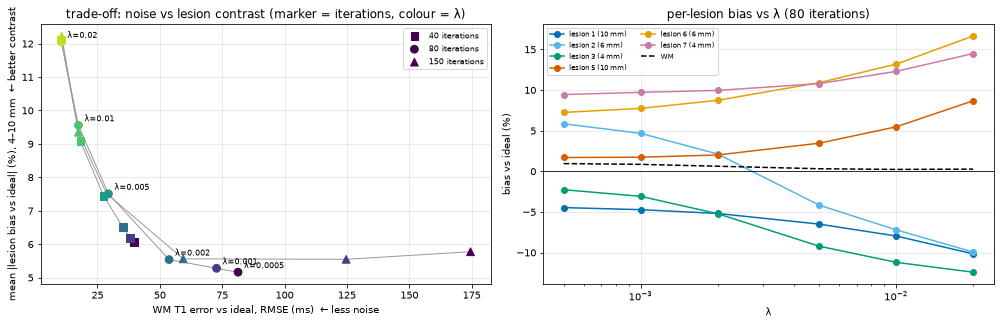

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
MK = {40: 's', 80: 'o', 150: '^'}
for it in S1_ITERS:
    x = [R1[l, it]['rmse_wm'] for l in S1_LAMBDAS]; y = [R1[l, it]['les_abs'] for l in S1_LAMBDAS]
    ax[0].plot(x, y, '-', color='0.6', lw=1, zorder=1)
    ax[0].scatter(x, y, c=COL, marker=MK[it], s=60, zorder=2, label=f'{it} iterations')
for l, c in zip(S1_LAMBDAS, COL):
    ax[0].annotate(f'λ={l}', (R1[l, 80]['rmse_wm'], R1[l, 80]['les_abs']), textcoords='offset points', xytext=(6, 4), fontsize=8)
ax[0].set_xlabel('WM T1 error vs ideal, RMSE (ms)  ← less noise'); ax[0].set_ylabel('mean |lesion bias vs ideal| (%), 4–10 mm  ← better contrast')
ax[0].set_title('trade-off: noise vs lesion contrast (marker = iterations, colour = λ)'); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=8)
for j, i in enumerate(LES):
    ax[1].plot(S1_LAMBDAS, [R1[l, 80]['rows'][i]['bias_vs_ideal_pct'] for l in S1_LAMBDAS], 'o-',
               color=['#0072B2', '#56B4E9', '#009E73', '#D55E00', '#E69F00', '#CC79A7'][j], label=R1[S1_LAMBDAS[0], 80]['rows'][i]['region'])
ax[1].plot(S1_LAMBDAS, [R1[l, 80]['rows'][0]['bias_vs_ideal_pct'] for l in S1_LAMBDAS], 'k--', label='WM')
ax[1].set_xscale('log'); ax[1].axhline(0, color='k', lw=0.8); ax[1].set_xlabel('λ'); ax[1].set_ylabel('bias vs ideal (%)')
ax[1].set_title('per-lesion bias vs λ (80 iterations)'); ax[1].grid(alpha=0.3); ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### Stage 1 reading (2026-10-02)

**Convergence.** For λ ≥ 0.005 the reconstruction has converged by 40–80 iterations: the
images change by ≤ 5 % between 40 and 150 iterations and every metric moves by < 1 ms or < 1
percentage point. For λ ≤ 0.002 it does **not** converge: noise keeps growing with iterations
(WM error 40 → 81 → 175 ms at λ = 0.0005 for 40 / 80 / 150 iterations; the checkerboard pattern
in the profiles is noise amplified by the undersampling), so there the iteration count, not λ, is
acting as the regulariser. That regime is fragile (the result depends on when FISTA is stopped)
and is avoided.

**Trade-off (80 iterations).**

| λ | WM error (RMSE vs ideal) | GM error | mean \|lesion bias\| (4–10 mm) | short-T1 lesions 10 / 6 / 4 mm | long-T1 lesions 10 / 6 / 4 mm |
|---|---|---|---|---|---|
| 0.002 | 54 ms | 53 ms | 5.5 % | +2.0 / +8.7 / +10.0 % | −5.2 / +2.1 / −5.2 % |
| 0.005 | 29 ms | 32 ms | 7.5 % | +3.5 / +10.9 / +10.8 % | −6.5 / −4.2 / −9.2 % |
| 0.01 | 17 ms | 22 ms | 9.6 % | +5.5 / +13.2 / +12.3 % | −8.0 / −7.2 / −11.2 % |
| 0.02 | 11 ms | 17 ms | 12.1 % | +8.7 / +16.6 / +14.5 % | −10.2 / −9.9 / −12.4 % |

Each doubling of λ cuts the WM error by ~40 % and costs
~2.5 points of lesion contrast. WM and GM mean T1 stay within 1 % of ideal at every setting.

**The lesion bias does not go to zero at small λ.** It levels off at ~5 % (short-T1 lesions
+7 to +10 %) even where noise is huge. On noise-free data with the same true maps (task 1) the
bias at small λ was ≈ 0, so this floor comes from **noise**, not from the regulariser: a
nonlinear T1 fit of noisy voxels in a 2–32-voxel region is biased, and near the null the signed
signal of the short-T1 lesions is small. Going below λ = 0.005 therefore buys little lesion
contrast for a large increase in noise.

**Recommendation (to be confirmed by eye on the grids).** λ in **0.005–0.01**, **80
iterations**. 0.005 keeps more lesion contrast; 0.01 gives visibly cleaner maps (WM error 17 vs
29 ms). The later 3-plane combination averages three acquisitions, which lowers noise further but
does not remove a regulariser bias; that argues for the lower end, λ* = 0.005. Stage 3 (a weaker
penalty on the T1-carrying coefficients) aims directly at this trade-off. Caveat for real data:
the phantom's piecewise-smooth anatomy is sparser in wavelets than a real brain, so the same λ
will smooth real cortex more; plan a short confirmation sweep (0.0025 / 0.005 / 0.01) on real
data.